In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data = pd.read_csv("intelligent_streetlight_dataset.csv")
data.head(10)

,Timestamp,Street ID,Day/Night,Traffic Count,Traffic Density,Traffic Speed,Ambient Light (lux),Weather,Energy Consumption (kWh),Power State,Dim Level,Latitude,Longitude,Special Event,Holiday/Weekend
0,2024-01-21 05:27:00,8,Day,154,41.750173,59.383884,172.439065,Clear,0.37,1,50,40.877092,-73.813538,1,0
1,2024-01-11 12:15:00,3,Night,103,30.949961,24.208586,189.339042,Rainy,0.00,0,100,40.862553,-74.125943,0,0
2,2024-01-29 20:18:00,9,Night,203,32.089607,29.733312,200.236036,Cloudy,0.00,0,75,40.809826,-73.853724,1,0
3,2024-01-05 13:42:00,5,Day,161,27.758249,27.850047,197.078404,Cloudy,0.78,1,100,40.529601,-74.073302,0,0
4,2024-01-08 07:45:00,1,Night,55,41.492456,59.282133,279.109775,Clear,0.46,1,50,40.565817,-74.116742,1,1
5,2024-01-26 17:13:00,6,Night,200,28.293919,23.986351,226.654123,Cloudy,0.83,1,100,40.728570,-73.859139,0,0
6,2024-01-15 17:21:00,2,Day,244,26.971331,48.980259,137.154322,Clear,0.00,0,50,40.751900,-73.771091,0,0
7,2024-01-12 04:06:00,6,Day,228,16.025011,46.700969,34.368789,Cloudy,0.43,1,100,40.552163,-74.166822,1,0
8,2024-01-10 17:16:00,1,Day,51,31.692600,58.172359,85.197577,Clear,0.00,0,75,40.569960,-73.884714,0,0
9,2024-01-23 08:54:00,1,Day,81,55.383021,47.332112,66.610264,Clear,0.00,0,100,40.603965,-74.059541,0,1


In [192]:
data.describe()

,Street ID,Traffic Count,Traffic Density,Traffic Speed,Ambient Light (lux),Energy Consumption (kWh),Power State,Dim Level,Latitude,Longitude,Special Event,Holiday/Weekend
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.508000,177.429000,35.047700,39.891310,171.234179,0.241780,0.503000,49.225000,40.702442,-73.946743,0.459000,0.498000
std,2.909364,70.064756,14.647251,11.603187,101.865321,0.291477,0.500241,35.969684,0.115534,0.142642,0.498566,0.500246
min,1.000000,50.000000,10.073398,20.036734,0.078170,0.000000,0.000000,0.000000,40.500899,-74.198446,0.000000,0.000000
25%,3.000000,118.000000,22.296820,29.682256,81.068828,0.000000,0.000000,25.000000,40.605432,-74.072035,0.000000,0.000000
50%,5.000000,179.000000,35.566512,39.294904,167.424778,0.075000,1.000000,50.000000,40.704036,-73.939872,0.000000,0.000000
75%,8.000000,237.250000,47.676395,49.999874,255.746741,0.460000,1.000000,75.000000,40.803821,-73.823415,1.000000,1.000000
max,10.000000,299.000000,59.993186,59.993270,349.747146,1.360000,1.000000,100.000000,40.899189,-73.700907,1.000000,1.000000


In [193]:
# Convert to relative time measurement from the t0, format YYYY-MM-DD HH:mm:ss.######
data["Timestamp"] = pd.to_datetime(
    data["Timestamp"],
    format="%Y-%m-%d %H:%M:%S"
)
data = data.sort_values(['Timestamp'])

t0 = data["Timestamp"].iloc[0]
data["Time Seconds"] = (data["Timestamp"] - t0).dt.total_seconds().astype(int)
data["Day Type"] = np.where(
    (data["Special Event"] == 0) & (data["Holiday/Weekend"] == 0),
    "Regular Day",
    "Event/Holiday/Weekend"
)
data.head(10)

,Timestamp,Street ID,Day/Night,Traffic Count,Traffic Density,Traffic Speed,Ambient Light (lux),Weather,Energy Consumption (kWh),Power State,Dim Level,Latitude,Longitude,Special Event,Holiday/Weekend,Time Seconds,Day Type
888,2024-01-01 00:13:00,4,Day,138,13.598167,42.184218,279.524143,Cloudy,0.00,0,75,40.629837,-74.021929,0,0,0,Regular Day
171,2024-01-01 00:21:00,6,Night,245,43.463640,23.873559,232.828946,Cloudy,0.90,1,100,40.649818,-74.032941,1,0,480,Event/Holiday/Weekend
586,2024-01-01 00:27:00,6,Night,96,46.103635,32.763675,68.878547,Rainy,0.18,1,75,40.897741,-73.939575,1,0,840,Event/Holiday/Weekend
360,2024-01-01 01:12:00,1,Night,211,45.825175,41.935423,172.657189,Clear,0.83,1,100,40.813486,-73.704274,1,0,3540,Event/Holiday/Weekend
849,2024-01-01 01:16:00,2,Night,262,12.700400,37.043547,265.588667,Clear,0.00,0,100,40.842534,-74.127582,1,0,3780,Event/Holiday/Weekend
152,2024-01-01 02:01:00,1,Day,55,28.241318,33.270998,276.910703,Rainy,0.00,0,0,40.709789,-73.959275,1,0,6480,Event/Holiday/Weekend
180,2024-01-01 02:58:00,2,Night,147,29.174147,46.317485,7.878488,Cloudy,0.00,0,75,40.809281,-73.832620,0,0,9900,Regular Day
43,2024-01-01 03:00:00,7,Night,229,25.151012,30.863811,205.705168,Cloudy,0.55,1,75,40.856372,-73.880830,1,0,10020,Event/Holiday/Weekend
199,2024-01-01 04:17:00,5,Night,153,30.793542,53.842745,218.676551,Clear,0.44,1,75,40.645602,-73.838843,1,1,14640,Event/Holiday/Weekend
540,2024-01-01 04:29:00,6,Night,174,18.032232,26.963304,223.167569,Clear,0.00,0,50,40.693682,-73.977515,1,0,15360,Event/Holiday/Weekend


In [194]:
# Unique value of "Steet ID" -> # samples, # Special Event, # Holiday/Weekend, # Special Holiday/Weekend, # Regualr Days, # Non-Regular Days
street_ids = sorted(data['Street ID'].unique())

t1 = pd.DataFrame([
    {
        'Street ID': street_id,
        '# samples': len(data[data['Street ID'] == street_id]),
        '# Special Events': (data[data['Street ID'] == street_id]['Special Event'] == 1).sum(),
        '# Holidays/Weekends': (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 1).sum(),
        '# Special Holidays/Weekends': ((data[data['Street ID'] == street_id]['Special Event'] == 1) & 
                                        (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 1)).sum(),
        '# Regular Days': ((data[data['Street ID'] == street_id]['Special Event'] == 0) & 
                          (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 0)).sum(),
        '# Events/Holidays/Weekends': ((data[data['Street ID'] == street_id]['Special Event'] == 1) | 
                                      (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 1)).sum(),
        '% Regular Days': round(((data[data['Street ID'] == street_id]['Special Event'] == 0) & 
                          (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 0)).sum()/len(data[data['Street ID'] == street_id])*100, 2),
        '% Events/Holidays/Weekends': round(((data[data['Street ID'] == street_id]['Special Event'] == 1) | 
                          (data[data['Street ID'] == street_id]['Holiday/Weekend'] == 1)).sum()/len(data[data['Street ID'] == street_id])*100,2)
    }
    for street_id in street_ids
])

t1

,Street ID,# samples,# Special Events,# Holidays/Weekends,# Special Holidays/Weekends,# Regular Days,# Events/Holidays/Weekends,% Regular Days,% Events/Holidays/Weekends
0,1,103,47,54,23,25,78,24.27,75.73
1,2,100,53,44,22,25,75,25.00,75.00
2,3,106,49,56,24,25,81,23.58,76.42
3,4,97,46,50,26,27,70,27.84,72.16
4,5,95,51,42,24,26,69,27.37,72.63
5,6,90,43,50,23,20,70,22.22,77.78
6,7,97,42,48,25,32,65,32.99,67.01
7,8,101,47,45,22,31,70,30.69,69.31
8,9,113,47,55,24,35,78,30.97,69.03
9,10,98,34,54,16,26,72,26.53,73.47


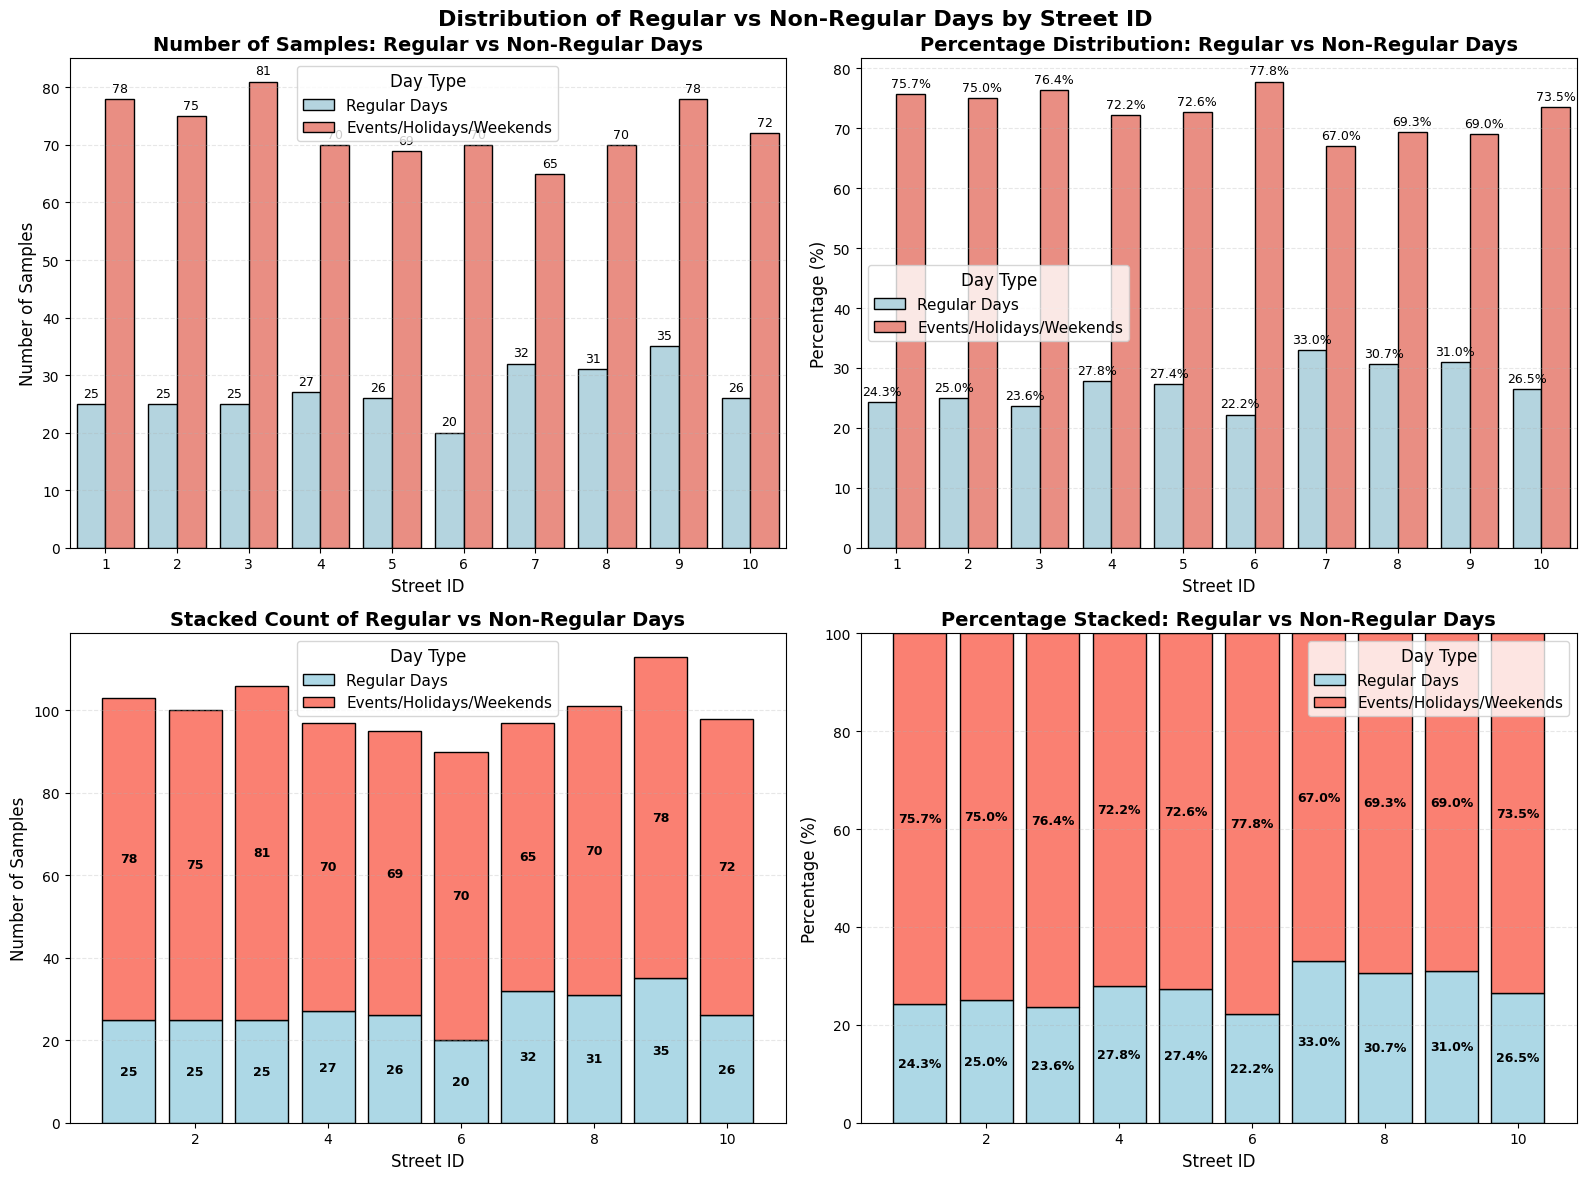


SUMMARY STATISTICS
Average Regular Days %: 27.15%
Average Events/Holidays/Weekends %: 72.85%
Street with highest Regular Days %: Street 7 (33.0%)
Street with highest Events/Holidays/Weekends %: Street 6 (77.8%)
Standard deviation of Regular Days %: 3.53%
Standard deviation of Events/Holidays/Weekends %: 3.53%


In [195]:
# 1. MELT the data for better plotting
# Create a long format for the count data
count_data = t1[['Street ID', '# Regular Days', '# Events/Holidays/Weekends']].copy()
count_data_melted = count_data.melt(
    id_vars='Street ID',
    value_vars=['# Regular Days', '# Events/Holidays/Weekends'],
    var_name='Day Type',
    value_name='Count'
)

# Create a long format for the percentage data
percent_data = t1[['Street ID', '% Regular Days', '% Events/Holidays/Weekends']].copy()
percent_data_melted = percent_data.melt(
    id_vars='Street ID',
    value_vars=['% Regular Days', '% Events/Holidays/Weekends'],
    var_name='Day Type',
    value_name='Percentage'
)

# Clean up the Day Type names
count_data_melted['Day Type'] = count_data_melted['Day Type'].str.replace('# ', '')
percent_data_melted['Day Type'] = percent_data_melted['Day Type'].str.replace('% ', '')

# 2. Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution of Regular vs Non-Regular Days by Street ID', fontsize=16, fontweight='bold')

# Palette for consistent coloring
palette = {'Regular Days': 'lightblue', 'Events/Holidays/Weekends': 'salmon'}

# 3. SUBPLOT 1: Count Bar Plot (Grouped)
ax1 = axes[0, 0]
sns.barplot(
    data=count_data_melted,
    x='Street ID',
    y='Count',
    hue='Day Type',
    palette=palette,
    ax=ax1,
    edgecolor='black'
)
ax1.set_title('Number of Samples: Regular vs Non-Regular Days', fontsize=14, fontweight='bold')
ax1.set_xlabel('Street ID', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.legend(title='Day Type', title_fontsize=12, fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=3, fontsize=9)

# 4. SUBPLOT 2: Percentage Bar Plot (Grouped)
ax2 = axes[0, 1]
sns.barplot(
    data=percent_data_melted,
    x='Street ID',
    y='Percentage',
    hue='Day Type',
    palette=palette,
    ax=ax2,
    edgecolor='black'
)
ax2.set_title('Percentage Distribution: Regular vs Non-Regular Days', fontsize=14, fontweight='bold')
ax2.set_xlabel('Street ID', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.legend(title='Day Type', title_fontsize=12, fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage labels on top of bars
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

# 5. SUBPLOT 3: Count Stacked Bar Plot
# Prepare data for stacked bar
ax3 = axes[1, 0]
bar_width = 0.8
bottom_positions = np.zeros(len(t1))

# Plot stacked bars
for day_type, color in [('Regular Days', 'lightblue'), ('Events/Holidays/Weekends', 'salmon')]:
    if day_type == 'Regular Days':
        values = t1['# Regular Days']
    else:
        values = t1['# Events/Holidays/Weekends']
    
    ax3.bar(
        t1['Street ID'],
        values,
        bottom=bottom_positions,
        width=bar_width,
        color=color,
        edgecolor='black',
        label=day_type
    )
    
    # Add labels in the middle of each segment
    for i, (street_id, value) in enumerate(zip(t1['Street ID'], values)):
        if value > 0:
            y_pos = bottom_positions[i] + value/2
            ax3.text(street_id, y_pos, f'{value}', 
                    ha='center', va='center', fontweight='bold', fontsize=9)
    
    bottom_positions += values

ax3.set_title('Stacked Count of Regular vs Non-Regular Days', fontsize=14, fontweight='bold')
ax3.set_xlabel('Street ID', fontsize=12)
ax3.set_ylabel('Number of Samples', fontsize=12)
ax3.legend(title='Day Type', title_fontsize=12, fontsize=11)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# 6. SUBPLOT 4: Percentage Stacked Bar Plot
ax4 = axes[1, 1]
bottom_positions = np.zeros(len(t1))

# Plot stacked percentage bars
for day_type, color in [('Regular Days', 'lightblue'), ('Events/Holidays/Weekends', 'salmon')]:
    if day_type == 'Regular Days':
        values = t1['% Regular Days']
    else:
        values = t1['% Events/Holidays/Weekends']
    
    ax4.bar(
        t1['Street ID'],
        values,
        bottom=bottom_positions,
        width=bar_width,
        color=color,
        edgecolor='black',
        label=day_type
    )
    
    # Add percentage labels in the middle of each segment
    for i, (street_id, value) in enumerate(zip(t1['Street ID'], values)):
        if value > 1:  # Only label if percentage is significant
            y_pos = bottom_positions[i] + value/2
            ax4.text(street_id, y_pos, f'{value:.1f}%', 
                    ha='center', va='center', fontweight='bold', fontsize=9, color='black')
    
    bottom_positions += values

ax4.set_title('Percentage Stacked: Regular vs Non-Regular Days', fontsize=14, fontweight='bold')
ax4.set_xlabel('Street ID', fontsize=12)
ax4.set_ylabel('Percentage (%)', fontsize=12)
ax4.legend(title='Day Type', title_fontsize=12, fontsize=11)
ax4.set_ylim(0, 100)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# 7. Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Average Regular Days %: {t1['% Regular Days'].mean():.2f}%")
print(f"Average Events/Holidays/Weekends %: {t1['% Events/Holidays/Weekends'].mean():.2f}%")
print(f"Street with highest Regular Days %: Street {t1.loc[t1['% Regular Days'].idxmax(), 'Street ID']} ({t1['% Regular Days'].max():.1f}%)")
print(f"Street with highest Events/Holidays/Weekends %: Street {t1.loc[t1['% Events/Holidays/Weekends'].idxmax(), 'Street ID']} ({t1['% Events/Holidays/Weekends'].max():.1f}%)")
print(f"Standard deviation of Regular Days %: {t1['% Regular Days'].std():.2f}%")
print(f"Standard deviation of Events/Holidays/Weekends %: {t1['% Events/Holidays/Weekends'].std():.2f}%")

DAY TYPE STATISTICS
                      Energy Consumption (kWh)                           \
                                          mean    std   min   max count   
Day Type                                                                  
Event/Holiday/Weekend                    0.480  0.233  0.07  1.36   368   
Regular Day                              0.482  0.231  0.07  1.07   135   

                      Ambient Light (lux)          Traffic Density          
                                     mean      std            mean     std  
Day Type                                                                    
Event/Holiday/Weekend             175.632  102.329          35.843  15.260  
Regular Day                       167.418  102.882          34.593  13.967  

DETAILED DAY TYPE ANALYSIS - STATISTICAL COMPARISON

SAMPLE COUNTS:
• Regular Days: 135 samples (26.8%)
• Event/Holiday/Weekends: 368 samples (73.2%)

ENERGY CONSUMPTION (kWh):
────────────────────────────────────────


C:\Users\dangs\AppData\Local\Temp\ipykernel_10492\2905300848.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


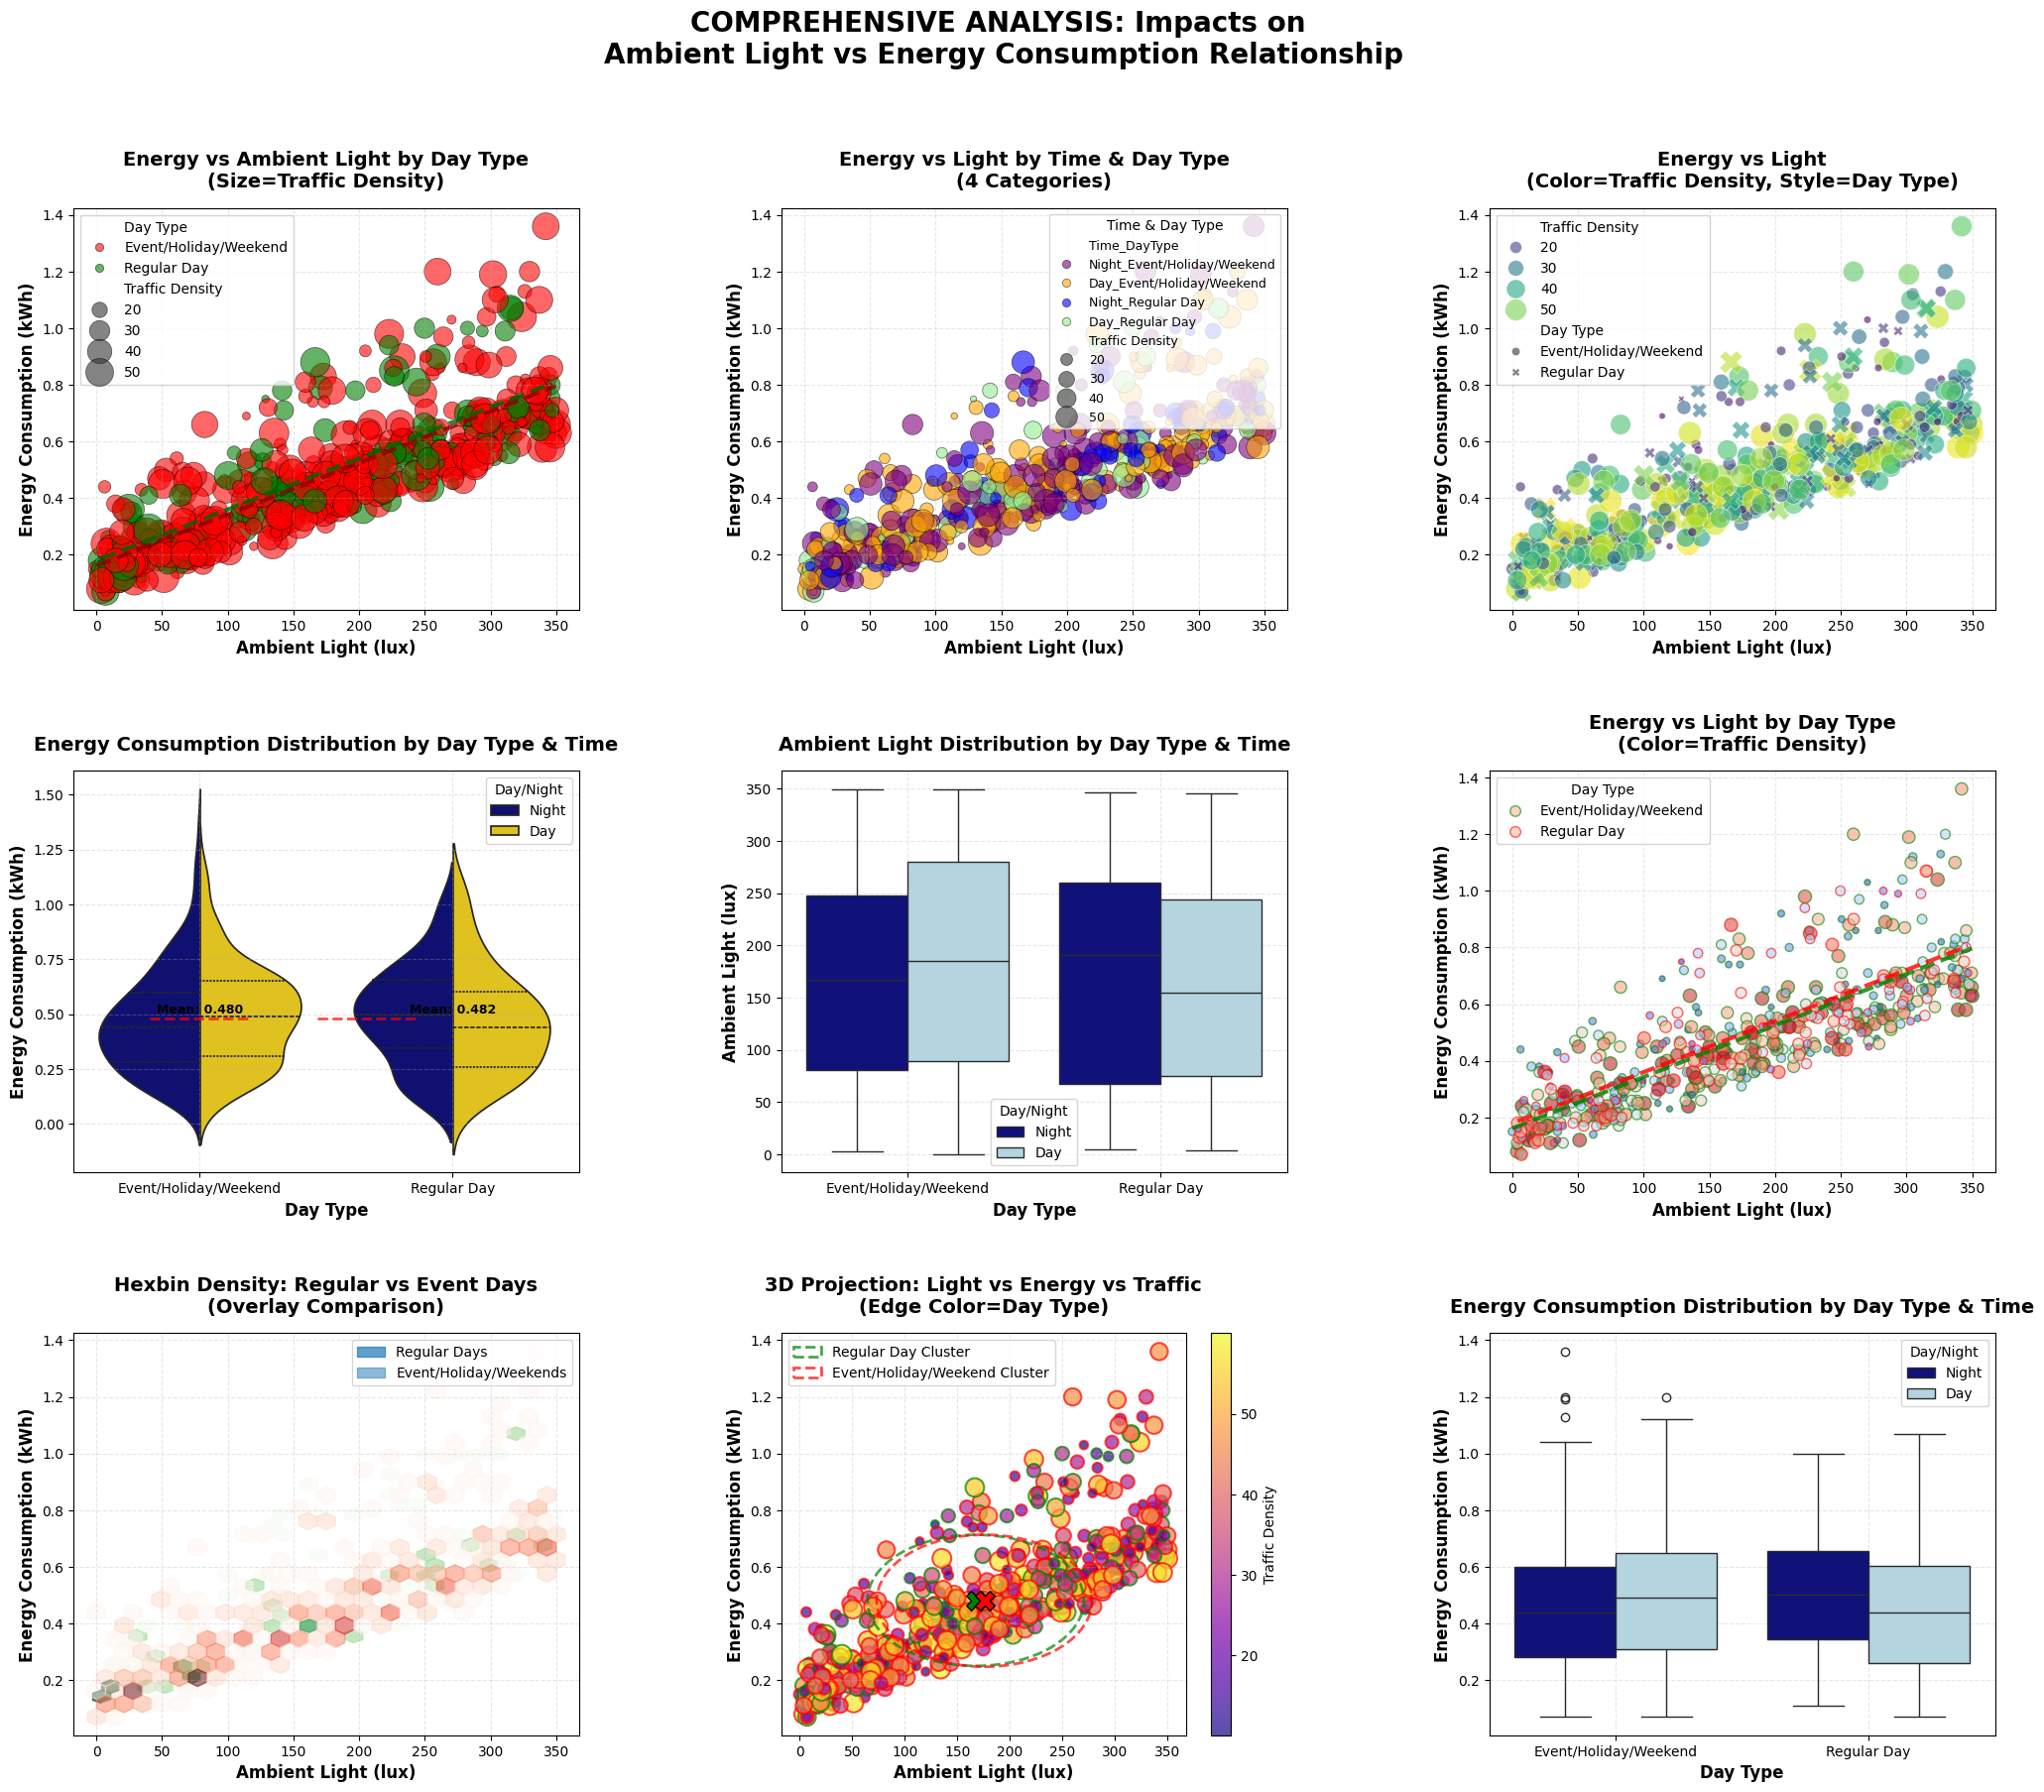

In [196]:
# Create a grid of subplots for different aspects
fig = plt.figure(figsize=(25, 20))  # Increased size for more plots
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1], hspace=0.4, wspace=0.4)
non_zero_energy = data[data["Energy Consumption (kWh)"] != 0].copy()

# Add Day Type column if not already present
non_zero_energy["Day Type"] = np.where(
    (non_zero_energy["Special Event"] == 0) & (non_zero_energy["Holiday/Weekend"] == 0),
    "Regular Day",
    "Event/Holiday/Weekend"
)

# Calculate basic statistics by Day Type
day_type_stats = non_zero_energy.groupby("Day Type").agg({
    "Energy Consumption (kWh)": ["mean", "std", "min", "max", "count"],
    "Ambient Light (lux)": ["mean", "std"],
    "Traffic Density": ["mean", "std"]
}).round(3)

print("="*80)
print("DAY TYPE STATISTICS")
print("="*80)
print(day_type_stats)

# 1. MAIN SCATTERPLOT WITH DAY TYPE COLOR (Top-left)
ax1 = fig.add_subplot(gs[0, 0])
scatter1 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Day Type",
    size="Traffic Density",
    sizes=(30, 500),
    alpha=0.6,
    palette={"Regular Day": "green", "Event/Holiday/Weekend": "red"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax1
)
ax1.set_title("Energy vs Ambient Light by Day Type\n(Size=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Add regression lines for each Day Type
for day_type, color in [("Regular Day", "darkgreen"), ("Event/Holiday/Weekend", "darkred")]:
    subset = non_zero_energy[non_zero_energy["Day Type"] == day_type]
    if len(subset) > 1:
        z = np.polyfit(subset["Ambient Light (lux)"], subset["Energy Consumption (kWh)"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(subset["Ambient Light (lux)"].min(), subset["Ambient Light (lux)"].max(), 100)
        ax1.plot(x_range, p(x_range), color=color, linewidth=3, linestyle="--", 
                alpha=0.8, label=f'{day_type} Trend')

# 2. SCATTERPLOT WITH DAY/NIGHT AND DAY TYPE FACET (Top-middle)
ax2 = fig.add_subplot(gs[0, 1])
# Create a combined category for detailed analysis
non_zero_energy["Time_DayType"] = non_zero_energy["Day/Night"] + "_" + non_zero_energy["Day Type"]

scatter2 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Time_DayType",
    size="Traffic Density",
    sizes=(20, 300),
    alpha=0.6,
    palette={"Day_Regular Day": "lightgreen", "Day_Event/Holiday/Weekend": "orange",
             "Night_Regular Day": "blue", "Night_Event/Holiday/Weekend": "purple"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax2
)
ax2.set_title("Energy vs Light by Time & Day Type\n(4 Categories)", 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(title="Time & Day Type", fontsize=9, title_fontsize=10, loc='upper right')

# 3. SCATTERPLOT WITH TRAFFIC DENSITY BY DAY TYPE (Top-right)
ax3 = fig.add_subplot(gs[0, 2])
scatter3 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Traffic Density",
    style="Day Type",
    size="Traffic Density",
    sizes=(20, 300),
    palette="viridis",
    alpha=0.6,
    ax=ax3
)
ax3.set_title("Energy vs Light\n(Color=Traffic Density, Style=Day Type)", 
              fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax3.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')

# 4. VIOLIN PLOTS COMPARING DAY TYPES (Middle-left)
ax4 = fig.add_subplot(gs[1, 0])
sns.violinplot(
    data=non_zero_energy,
    x="Day Type",
    y="Energy Consumption (kWh)",
    hue="Day/Night",
    split=True,
    palette={"Day": "gold", "Night": "navy"},
    inner="quartile",
    ax=ax4
)
ax4.set_title("Energy Consumption Distribution by Day Type & Time", 
              fontsize=14, fontweight='bold', pad=15)
ax4.set_xlabel("Day Type", fontsize=12, fontweight='bold')
ax4.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--')

# Add mean lines
for i, day_type in enumerate(non_zero_energy["Day Type"].unique()):
    subset = non_zero_energy[non_zero_energy["Day Type"] == day_type]
    mean_val = subset["Energy Consumption (kWh)"].mean()
    ax4.axhline(y=mean_val, xmin=i/3 + 0.15, xmax=i/3 + 0.35, 
               color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax4.text(i, mean_val*1.02, f'Mean: {mean_val:.3f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)

# 5. BOX PLOTS OF AMBIENT LIGHT BY DAY TYPE (Middle-middle)
ax5 = fig.add_subplot(gs[1, 1])
sns.boxplot(
    data=non_zero_energy,
    x="Day Type",
    y="Ambient Light (lux)",
    hue="Day/Night",
    palette={"Day": "lightblue", "Night": "darkblue"},
    ax=ax5
)
ax5.set_title("Ambient Light Distribution by Day Type & Time", 
              fontsize=14, fontweight='bold', pad=15)
ax5.set_xlabel("Day Type", fontsize=12, fontweight='bold')
ax5.set_ylabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, linestyle='--')
# ax5.set_yscale('log')  # Log scale for better visualization

# 6. SCATTER WITH FACET GRID BY DAY TYPE (Middle-right)
ax6 = fig.add_subplot(gs[1, 2])
# Create a facet-like visualization manually
day_types = non_zero_energy["Day Type"].unique()
colors = ['green', 'red']

for i, day_type in enumerate(day_types):
    subset = non_zero_energy[non_zero_energy["Day Type"] == day_type]
    ax6.scatter(
        subset["Ambient Light (lux)"],
        subset["Energy Consumption (kWh)"],
        c=subset["Traffic Density"],
        cmap="coolwarm",
        s=subset["Traffic Density"]/non_zero_energy["Traffic Density"].max() * 100,
        alpha=0.6,
        edgecolors=colors[i],
        linewidth=1,
        label=day_type
    )
    
    # Add regression line for each day type
    if len(subset) > 1:
        z = np.polyfit(subset["Ambient Light (lux)"], subset["Energy Consumption (kWh)"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(subset["Ambient Light (lux)"].min(), subset["Ambient Light (lux)"].max(), 100)
        ax6.plot(x_range, p(x_range), color=colors[i], linewidth=3, linestyle="--", alpha=0.8)

ax6.set_title("Energy vs Light by Day Type\n(Color=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax6.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax6.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.legend(title="Day Type")

# 7. HEXBIN WITH DAY TYPE SEPARATION (Bottom-left)
ax7 = fig.add_subplot(gs[2, 0])
# Create separate hexbin plots
regular_data = non_zero_energy[non_zero_energy["Day Type"] == "Regular Day"]
event_data = non_zero_energy[non_zero_energy["Day Type"] == "Event/Holiday/Weekend"]

# Regular Days hexbin
hex1 = ax7.hexbin(
    regular_data["Ambient Light (lux)"],
    regular_data["Energy Consumption (kWh)"],
    gridsize=25,
    cmap="Greens",
    alpha=0.7,
    mincnt=1,
    label="Regular Days"
)

# Event/Holiday/Weekends hexbin (overlay)
hex2 = ax7.hexbin(
    event_data["Ambient Light (lux)"],
    event_data["Energy Consumption (kWh)"],
    gridsize=25,
    cmap="Reds",
    alpha=0.5,
    mincnt=1,
    label="Event/Holiday/Weekends"
)

ax7.set_title("Hexbin Density: Regular vs Event Days\n(Overlay Comparison)", 
              fontsize=14, fontweight='bold', pad=15)
ax7.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax7.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3, linestyle='--')
ax7.legend()

# 8. 3D SCATTER PROJECTION (Bottom-middle)
ax8 = fig.add_subplot(gs[2, 1])
# Create a 2D scatter with third dimension as color and fourth as size
scatter8 = ax8.scatter(
    non_zero_energy["Ambient Light (lux)"],
    non_zero_energy["Energy Consumption (kWh)"],
    c=non_zero_energy["Traffic Density"],
    cmap="plasma",
    s=non_zero_energy["Traffic Density"]/non_zero_energy["Traffic Density"].max() * 200,
    alpha=0.7,
    edgecolors=non_zero_energy["Day Type"].map({"Regular Day": "green", "Event/Holiday/Weekend": "red"}),
    linewidth=1.5
)

# Add ellipses for each Day Type cluster
from matplotlib.patches import Ellipse
for day_type, color in [("Regular Day", "green"), ("Event/Holiday/Weekend", "red")]:
    subset = non_zero_energy[non_zero_energy["Day Type"] == day_type]
    if len(subset) > 10:
        mean_x = subset["Ambient Light (lux)"].mean()
        mean_y = subset["Energy Consumption (kWh)"].mean()
        std_x = subset["Ambient Light (lux)"].std()
        std_y = subset["Energy Consumption (kWh)"].std()
        
        ellipse = Ellipse(
            (mean_x, mean_y),
            width=std_x * 2,
            height=std_y * 2,
            angle=0,
            fill=False,
            edgecolor=color,
            linewidth=2,
            linestyle="--",
            alpha=0.7,
            label=f'{day_type} Cluster'
        )
        ax8.add_patch(ellipse)
        
        # Add centroid marker
        ax8.scatter(mean_x, mean_y, color=color, s=200, marker='X', edgecolor='black', linewidth=1)

ax8.set_title("3D Projection: Light vs Energy vs Traffic\n(Edge Color=Day Type)", 
              fontsize=14, fontweight='bold', pad=15)
ax8.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax8.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3, linestyle='--')
ax8.legend()
plt.colorbar(scatter8, ax=ax8, label="Traffic Density")

# 9. BOX PLOTS OF AMBIENT LIGHT BY DAY TYPE (Middle-middle)
ax9 = fig.add_subplot(gs[2, 2])
sns.boxplot(
    data=non_zero_energy,
    x="Day Type",
    y="Energy Consumption (kWh)",
    hue="Day/Night",
    palette={"Day": "lightblue", "Night": "darkblue"},
    ax=ax9
)
ax9.set_title("Energy Consumption Distribution by Day Type & Time", 
              fontsize=14, fontweight='bold', pad=15)
ax9.set_xlabel("Day Type", fontsize=12, fontweight='bold')
ax9.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3, linestyle='--')

# Calculate detailed statistics
regular_stats = non_zero_energy[non_zero_energy["Day Type"] == "Regular Day"]
event_stats = non_zero_energy[non_zero_energy["Day Type"] == "Event/Holiday/Weekend"]

# Perform statistical tests
if len(regular_stats) > 0 and len(event_stats) > 0:
    # T-test for energy consumption
    t_stat_energy, p_val_energy = stats.ttest_ind(
        regular_stats["Energy Consumption (kWh)"],
        event_stats["Energy Consumption (kWh)"],
        equal_var=False
    )
    
    # T-test for ambient light
    t_stat_light, p_val_light = stats.ttest_ind(
        regular_stats["Ambient Light (lux)"],
        event_stats["Ambient Light (lux)"],
        equal_var=False
    )
    
    # T-test for traffic density
    t_stat_traffic, p_val_traffic = stats.ttest_ind(
        regular_stats["Traffic Density"],
        event_stats["Traffic Density"],
        equal_var=False
    )

print(f"""
DETAILED DAY TYPE ANALYSIS - STATISTICAL COMPARISON
{'='*80}

SAMPLE COUNTS:
• Regular Days: {len(regular_stats):,} samples ({len(regular_stats)/len(non_zero_energy)*100:.1f}%)
• Event/Holiday/Weekends: {len(event_stats):,} samples ({len(event_stats)/len(non_zero_energy)*100:.1f}%)

ENERGY CONSUMPTION (kWh):
{'─'*40}
                Regular Days      Event/Holidays    Difference    % Change
Mean:           {regular_stats['Energy Consumption (kWh)'].mean():10.3f}   {event_stats['Energy Consumption (kWh)'].mean():10.3f}   {event_stats['Energy Consumption (kWh)'].mean() - regular_stats['Energy Consumption (kWh)'].mean():10.3f}   {(event_stats['Energy Consumption (kWh)'].mean() - regular_stats['Energy Consumption (kWh)'].mean())/regular_stats['Energy Consumption (kWh)'].mean()*100:7.1f}%
Std Dev:        {regular_stats['Energy Consumption (kWh)'].std():10.3f}   {event_stats['Energy Consumption (kWh)'].std():10.3f}
Min:            {regular_stats['Energy Consumption (kWh)'].min():10.3f}   {event_stats['Energy Consumption (kWh)'].min():10.3f}
Max:            {regular_stats['Energy Consumption (kWh)'].max():10.3f}   {event_stats['Energy Consumption (kWh)'].max():10.3f}
T-test p-value: {'':10s}   {'':10s}   {'':10s}   {p_val_energy:7.4f}

AMBIENT LIGHT (lux):
{'─'*40}
                Regular Days      Event/Holidays    Difference    % Change
Mean:           {regular_stats['Ambient Light (lux)'].mean():10.1f}   {event_stats['Ambient Light (lux)'].mean():10.1f}   {event_stats['Ambient Light (lux)'].mean() - regular_stats['Ambient Light (lux)'].mean():10.1f}   {(event_stats['Ambient Light (lux)'].mean() - regular_stats['Ambient Light (lux)'].mean())/regular_stats['Ambient Light (lux)'].mean()*100:7.1f}%
Std Dev:        {regular_stats['Ambient Light (lux)'].std():10.1f}   {event_stats['Ambient Light (lux)'].std():10.1f}
T-test p-value: {'':10s}   {'':10s}   {'':10s}   {p_val_light:7.4f}

TRAFFIC DENSITY:
{'─'*40}
                Regular Days      Event/Holidays    Difference    % Change
Mean:           {regular_stats['Traffic Density'].mean():10.1f}   {event_stats['Traffic Density'].mean():10.1f}   {event_stats['Traffic Density'].mean() - regular_stats['Traffic Density'].mean():10.1f}   {(event_stats['Traffic Density'].mean() - regular_stats['Traffic Density'].mean())/regular_stats['Traffic Density'].mean()*100:7.1f}%
Std Dev:        {regular_stats['Traffic Density'].std():10.1f}   {event_stats['Traffic Density'].std():10.1f}
T-test p-value: {'':10s}   {'':10s}   {'':10s}   {p_val_traffic:7.4f}

CORRELATION ANALYSIS:
{'─'*40}
                       Regular Days    Event/Holidays   Difference
Light-Energy:         {regular_stats['Ambient Light (lux)'].corr(regular_stats['Energy Consumption (kWh)']):12.3f}   {event_stats['Ambient Light (lux)'].corr(event_stats['Energy Consumption (kWh)']):12.3f}   {event_stats['Ambient Light (lux)'].corr(event_stats['Energy Consumption (kWh)']) - regular_stats['Ambient Light (lux)'].corr(regular_stats['Energy Consumption (kWh)']):12.3f}
Traffic-Energy:       {regular_stats['Traffic Density'].corr(regular_stats['Energy Consumption (kWh)']):12.3f}   {event_stats['Traffic Density'].corr(event_stats['Energy Consumption (kWh)']):12.3f}   {event_stats['Traffic Density'].corr(event_stats['Energy Consumption (kWh)']) - regular_stats['Traffic Density'].corr(regular_stats['Energy Consumption (kWh)']):12.3f}
Light-Traffic:        {regular_stats['Ambient Light (lux)'].corr(regular_stats['Traffic Density']):12.3f}   {event_stats['Ambient Light (lux)'].corr(event_stats['Traffic Density']):12.3f}   {event_stats['Ambient Light (lux)'].corr(event_stats['Traffic Density']) - regular_stats['Ambient Light (lux)'].corr(regular_stats['Traffic Density']):12.3f}

KEY INSIGHTS:
{'─'*40}
1. Energy Consumption: {'Higher on Event Days' if event_stats['Energy Consumption (kWh)'].mean() > regular_stats['Energy Consumption (kWh)'].mean() else 'Higher on Regular Days'}
2. Light Sensitivity: {'Stronger correlation on Event Days' if abs(event_stats['Ambient Light (lux)'].corr(event_stats['Energy Consumption (kWh)'])) > abs(regular_stats['Ambient Light (lux)'].corr(regular_stats['Energy Consumption (kWh)'])) else 'Stronger correlation on Regular Days'}
3. Traffic Impact: {'More influential on Event Days' if abs(event_stats['Traffic Density'].corr(event_stats['Energy Consumption (kWh)'])) > abs(regular_stats['Traffic Density'].corr(regular_stats['Energy Consumption (kWh)'])) else 'More influential on Regular Days'}
4. Statistical Significance (p < 0.05):
   • Energy: {'SIGNIFICANT' if p_val_energy < 0.05 else 'NOT SIGNIFICANT'}
   • Light: {'SIGNIFICANT' if p_val_light < 0.05 else 'NOT SIGNIFICANT'}
   • Traffic: {'SIGNIFICANT' if p_val_traffic < 0.05 else 'NOT SIGNIFICANT'}
""")

plt.suptitle("COMPREHENSIVE ANALYSIS: Impacts on \nAmbient Light vs Energy Consumption Relationship", 
             fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()




STATISTICAL ANALYSIS OF AMBIENT LIGHT VS ENERGY CONSUMPTION

Overall Statistics:
• Total Samples: 503
• Ambient Light Range: 0.1 - 349.7 lux
• Energy Consumption Range: 0.07 - 1.36 kWh
• Traffic Density Range: 10.1 - 60.0

Correlation Analysis:
• Light-Energy Correlation: 0.798
• Traffic-Energy Correlation: -0.047
• Light-Traffic Correlation: -0.007

Average Energy Consumption:
• Daytime Average: 0.488 kWh
• Nighttime Average: 0.474 kWh
• Difference: -0.015 kWh

Traffic Impact:
• High Traffic (Top 25%): Avg Energy = 0.449 kWh
• Low Traffic (Bottom 25%): Avg Energy = 0.476 kWh



C:\Users\dangs\AppData\Local\Temp\ipykernel_10492\3874200087.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


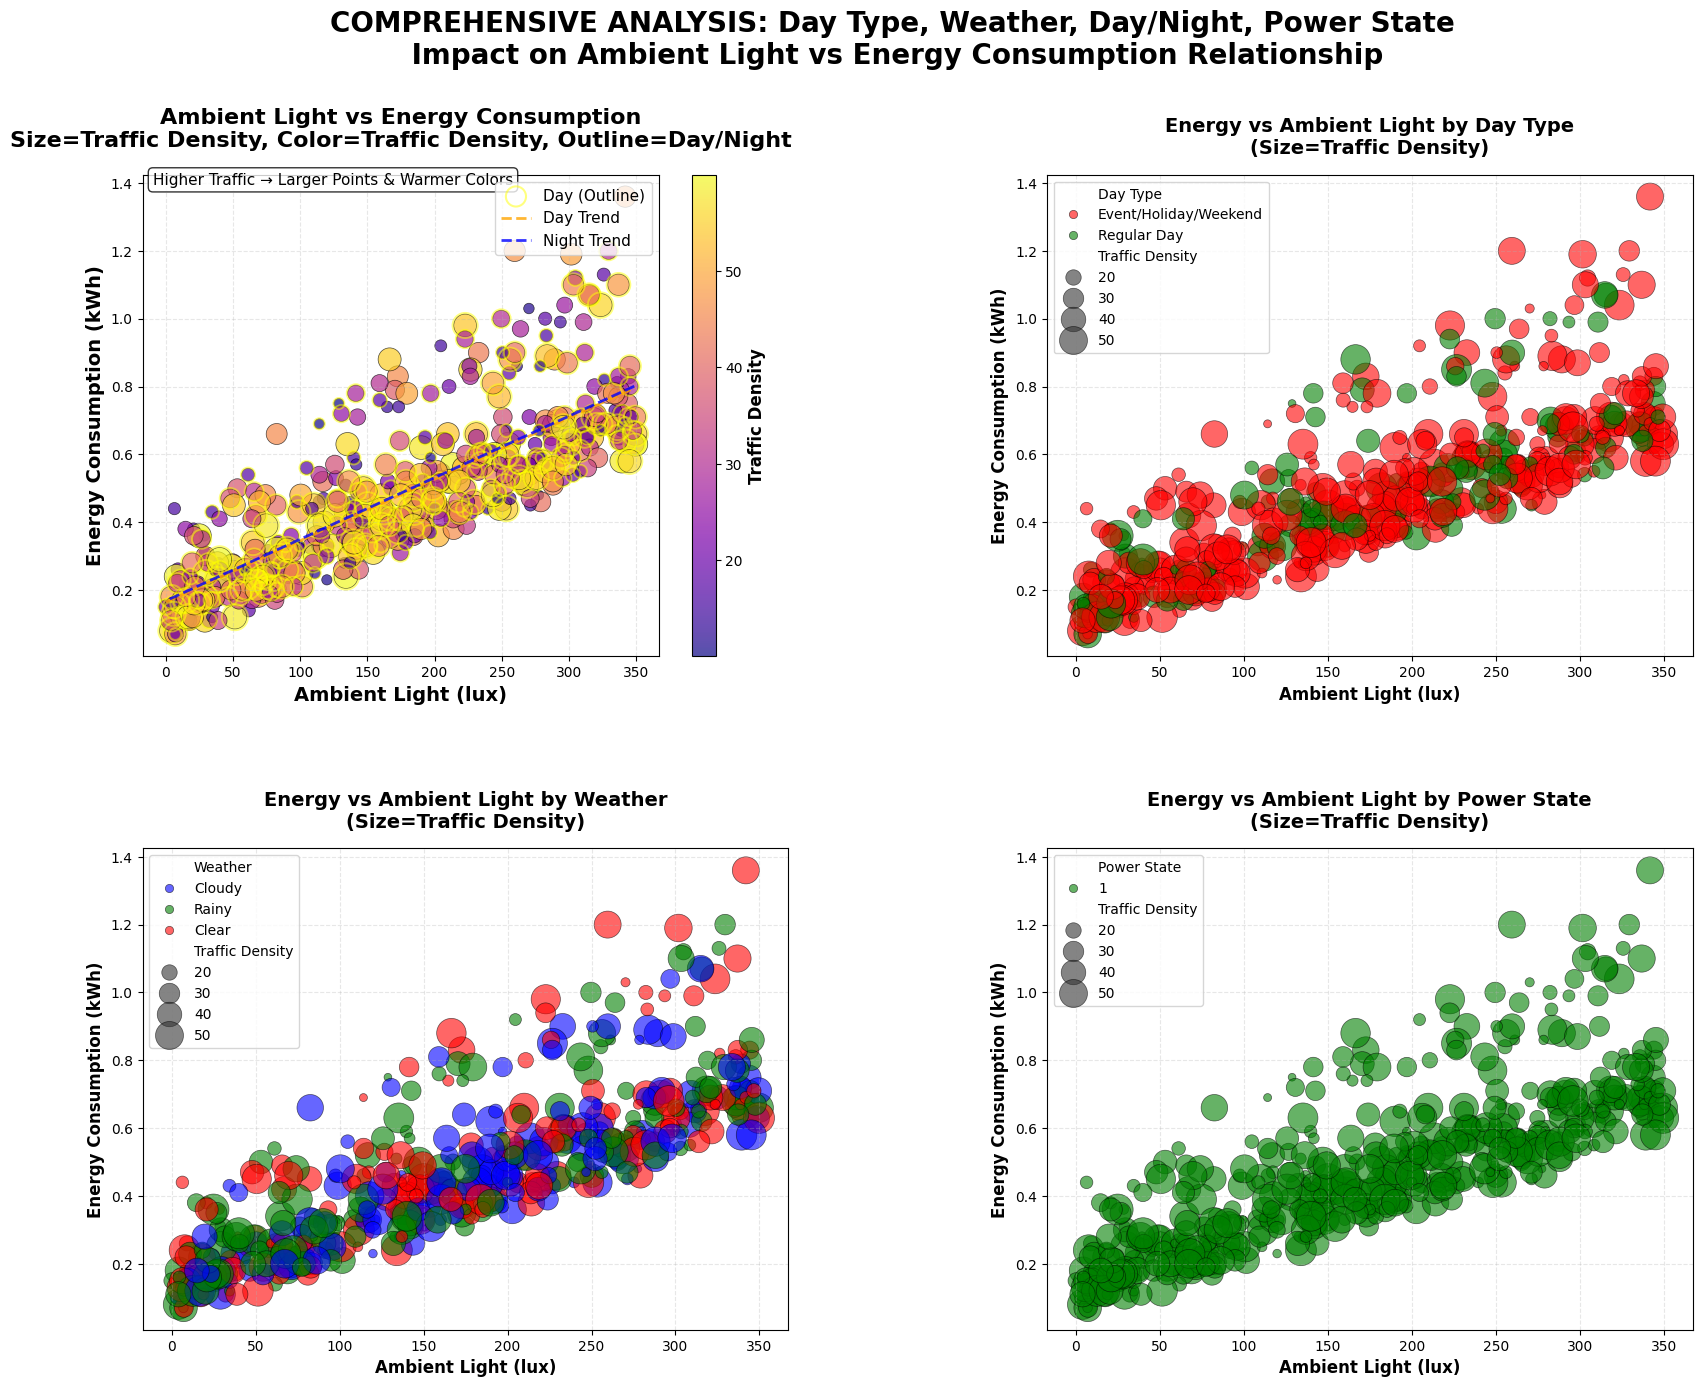

In [197]:
# Calculate statistics
print(f"""
STATISTICAL ANALYSIS OF AMBIENT LIGHT VS ENERGY CONSUMPTION

Overall Statistics:
• Total Samples: {len(non_zero_energy):,}
• Ambient Light Range: {non_zero_energy['Ambient Light (lux)'].min():.1f} - {non_zero_energy['Ambient Light (lux)'].max():.1f} lux
• Energy Consumption Range: {non_zero_energy['Energy Consumption (kWh)'].min():.2f} - {non_zero_energy['Energy Consumption (kWh)'].max():.2f} kWh
• Traffic Density Range: {non_zero_energy['Traffic Density'].min():.1f} - {non_zero_energy['Traffic Density'].max():.1f}

Correlation Analysis:
• Light-Energy Correlation: {non_zero_energy['Ambient Light (lux)'].corr(non_zero_energy['Energy Consumption (kWh)']):.3f}
• Traffic-Energy Correlation: {non_zero_energy['Traffic Density'].corr(non_zero_energy['Energy Consumption (kWh)']):.3f}
• Light-Traffic Correlation: {non_zero_energy['Ambient Light (lux)'].corr(non_zero_energy['Traffic Density']):.3f}

Average Energy Consumption:
• Daytime Average: {non_zero_energy[non_zero_energy['Day/Night'] == 'Day']['Energy Consumption (kWh)'].mean():.3f} kWh
• Nighttime Average: {non_zero_energy[non_zero_energy['Day/Night'] == 'Night']['Energy Consumption (kWh)'].mean():.3f} kWh
• Difference: {(non_zero_energy[non_zero_energy['Day/Night'] == 'Night']['Energy Consumption (kWh)'].mean() - non_zero_energy[non_zero_energy['Day/Night'] == 'Day']['Energy Consumption (kWh)'].mean()):.3f} kWh

Traffic Impact:
• High Traffic (Top 25%): Avg Energy = {non_zero_energy[non_zero_energy['Traffic Density'] > non_zero_energy['Traffic Density'].quantile(0.75)]['Energy Consumption (kWh)'].mean():.3f} kWh
• Low Traffic (Bottom 25%): Avg Energy = {non_zero_energy[non_zero_energy['Traffic Density'] < non_zero_energy['Traffic Density'].quantile(0.25)]['Energy Consumption (kWh)'].mean():.3f} kWh
""")

fig = plt.figure(figsize=(20,15))  # Increased size for more plots
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.4, wspace=0.4)

# Create scatterplot with multiple encodings
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(
    non_zero_energy["Ambient Light (lux)"],
    non_zero_energy["Energy Consumption (kWh)"],
    c=non_zero_energy["Traffic Density"],
    cmap="plasma",
    s=non_zero_energy["Traffic Density"]/non_zero_energy["Traffic Density"].max() * 300,  # Dynamic sizing
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5
)

# Add Day/Night encoding with different markers
day_mask = non_zero_energy["Day/Night"] == "Day"
ax1.scatter(
    non_zero_energy.loc[day_mask, "Ambient Light (lux)"],
    non_zero_energy.loc[day_mask, "Energy Consumption (kWh)"],
    facecolors='none',
    edgecolors='yellow',
    s=non_zero_energy.loc[day_mask, "Traffic Density"]/non_zero_energy["Traffic Density"].max() * 300 * 1.2,
    linewidth=1.5,
    alpha=0.5,
    label='Day (Outline)'
)

# Add regression lines for Day and Night
for day_night, color in [("Day", "orange"), ("Night", "blue")]:
    subset = non_zero_energy[non_zero_energy["Day/Night"] == day_night]
    if len(subset) > 1:
        z = np.polyfit(subset["Ambient Light (lux)"], subset["Energy Consumption (kWh)"], 1)
        p = np.poly1d(z)
        x_range = np.linspace(subset["Ambient Light (lux)"].min(), subset["Ambient Light (lux)"].max(), 100)
        ax1.plot(x_range, p(x_range), color=color, linewidth=2, linestyle="--", 
                label=f'{day_night} Trend', alpha=0.8)

ax1.set_title("Ambient Light vs Energy Consumption\nSize=Traffic Density, Color=Traffic Density, Outline=Day/Night", 
             fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel("Ambient Light (lux)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Energy Consumption (kWh)", fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper right', fontsize=11)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Traffic Density', fontsize=12, fontweight='bold')

# Add annotations for key insights
ax1.annotate('Higher Traffic → Larger Points & Warmer Colors', 
            xy=(0.02, 0.98), xycoords='axes fraction',
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2 = fig.add_subplot(gs[0, 1])
scatter2 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Day Type",
    size="Traffic Density",
    sizes=(30, 500),
    alpha=0.6,
    palette={"Regular Day": "green", "Event/Holiday/Weekend": "red"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax2
)
ax2.set_title("Energy vs Ambient Light by Day Type\n(Size=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')

ax3 = fig.add_subplot(gs[1, 0])
scatter3 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Weather",
    size="Traffic Density",
    sizes=(30, 500),
    alpha=0.6,
    palette={"Clear": "red", "Rainy": "green", "Cloudy":"blue"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax3
)
ax3.set_title("Energy vs Ambient Light by Weather\n(Size=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax3.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')

ax4 = fig.add_subplot(gs[1, 1])
scatter4 = sns.scatterplot(
    data=non_zero_energy,
    x="Ambient Light (lux)",
    y="Energy Consumption (kWh)",
    hue="Power State",
    size="Traffic Density",
    sizes=(30, 500),
    alpha=0.6,
    palette={1: "green", 0: "red"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax4
)
ax4.set_title("Energy vs Ambient Light by Power State\n(Size=Traffic Density)", 
              fontsize=14, fontweight='bold', pad=15)
ax4.set_xlabel("Ambient Light (lux)", fontsize=12, fontweight='bold')
ax4.set_ylabel("Energy Consumption (kWh)", fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--')

plt.suptitle("COMPREHENSIVE ANALYSIS: Day Type, Weather, Day/Night, Power State\n Impact on Ambient Light vs Energy Consumption Relationship", 
             fontsize=20, fontweight='bold', y=0.99)

plt.tight_layout()
plt.show()